In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Covid_data.csv")

In [3]:
df.columns = df.columns.str.strip()

In [4]:
df['State_UT'] = df['State_UT'].astype(str).str.strip().str.title()

In [5]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

In [6]:
df['Confirmed'] = df['Confirmed'].fillna(0)
df['Recovered'] = df['Recovered'].fillna(0)
df['Deaths'] = df['Deaths'].fillna(0)
df['Phase'] = df['Phase'].fillna('Not Specified')

In [7]:
df = df.drop_duplicates(subset=['State_UT', 'Date'])

In [8]:
df['Active'] = df['Confirmed'] - df['Recovered'] - df['Deaths']

In [9]:
num_cols = ['Confirmed', 'Recovered', 'Deaths', 'Active']
df[num_cols] = df[num_cols].clip(lower=0).round().astype(int)

In [10]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [11]:
df['Recovery_Rate'] = np.where(
    df['Confirmed'] > 0,
    (df['Recovered'] / df['Confirmed']) * 100,
    0
)

In [12]:
print(df)

          Date           State_UT  Confirmed  Recovered  Deaths  Active  \
0   2020-03-25  Andaman & Nicobar      17000      13260     306    3434   
1   2020-03-25     Andhra Pradesh        500        390       9     101   
2   2020-03-25  Arunachal Pradesh       1000        780      18     202   
3   2020-03-25              Assam       1500       1170      26     304   
4   2020-03-25              Bihar       2000       1560      36     404   
..         ...                ...        ...        ...     ...     ...   
267 2020-09-01          Telangana      20400      15912     367    4121   
268 2020-09-01            Tripura      20900      16302     376    4222   
269 2020-09-01      Uttar Pradesh      21400      16692     385    4323   
270 2020-09-01        Uttarakhand      21900      17082     394    4424   
271 2020-09-01        West Bengal      22400      17472     403    4525   

          Phase  Month  Year  Recovery_Rate  
0    Lockdown 1      3  2020           78.0  
1    Lo

In [13]:
top_states = (
    df.groupby('State_UT')['Confirmed']
    .max()
    .sort_values(ascending=False)
    .head(10)
)

In [14]:
print(top_states)

State_UT
Andaman & Nicobar    25400
Chandigarh           24900
Puducherry           24400
Ladakh               23900
Jammu & Kashmir      23400
Delhi                22900
West Bengal          22400
Uttarakhand          21900
Uttar Pradesh        21400
Tripura              20900
Name: Confirmed, dtype: int64


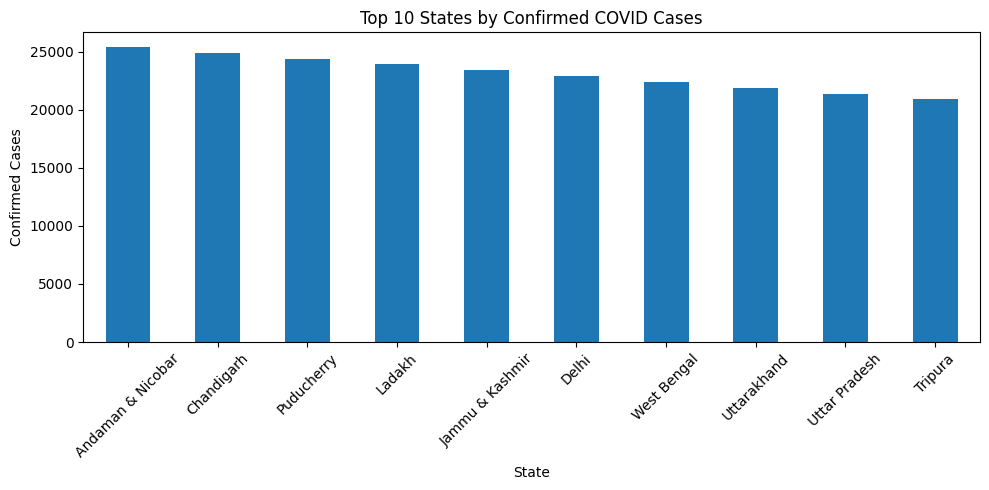

In [15]:
plt.figure(figsize=(10, 5))
top_states.plot(kind='bar')
plt.title("Top 10 States by Confirmed COVID Cases")
plt.xlabel("State")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
state = input("Enter State Name: ").strip().title()

Enter State Name:  Gujarat


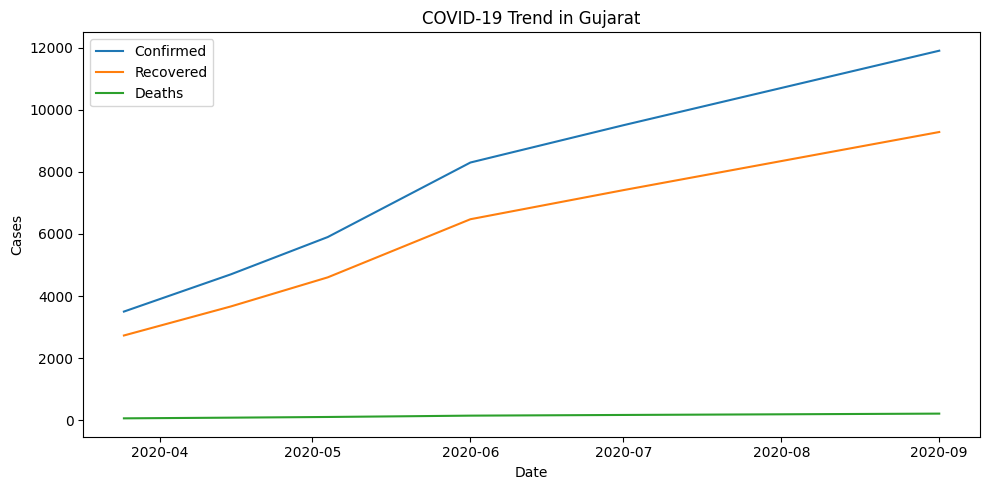

In [23]:
if state not in df['State_UT'].unique():
    print("❌ State not found!")
    print("\nAvailable States:")
    print(sorted(df['State_UT'].unique()))
else:
    state_df = df[df['State_UT'] == state].sort_values('Date')

    plt.figure(figsize=(10, 5))
    plt.plot(state_df['Date'], state_df['Confirmed'], label='Confirmed')
    plt.plot(state_df['Date'], state_df['Recovered'], label='Recovered')
    plt.plot(state_df['Date'], state_df['Deaths'], label='Deaths')
    plt.legend()
    plt.title(f"COVID-19 Trend in {state}")
    plt.xlabel("Date")
    plt.ylabel("Cases")
    plt.tight_layout()
    plt.show()

In [18]:
phase_avg = df.groupby('Phase')['Active'].mean()

In [24]:
print(phase_avg)

Phase
Lockdown 1    1767.941176
Lockdown 2    2010.500000
Lockdown 3    2252.500000
Lockdown 4    2495.500000
Unlock 1      2737.500000
Unlock 2      2979.941176
Unlock 3      3222.500000
Unlock 4      3464.500000
Name: Active, dtype: float64


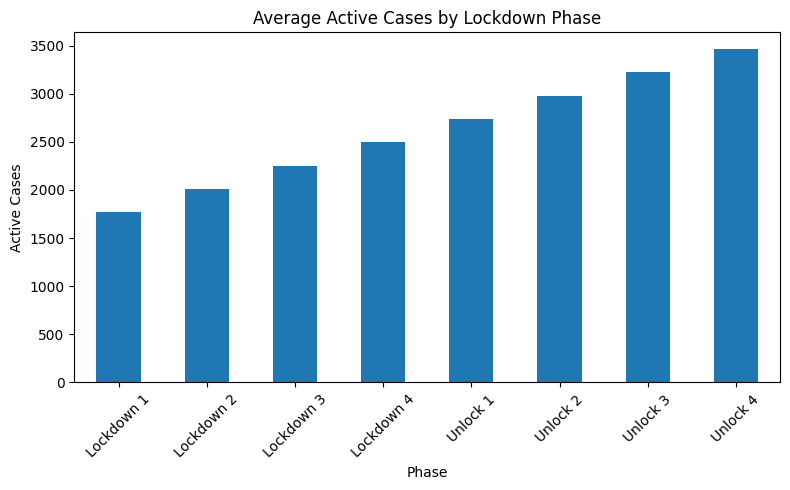

In [19]:
plt.figure(figsize=(8, 5))
phase_avg.plot(kind='bar')
plt.title("Average Active Cases by Lockdown Phase")
plt.xlabel("Phase")
plt.ylabel("Active Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
pivot = df.pivot_table(
    values='Active',
    index='State_UT',
    columns='Phase',
    aggfunc='mean'
).fillna(0)

In [26]:
print(pivot)

Phase              Lockdown 1  Lockdown 2  Lockdown 3  Lockdown 4  Unlock 1  \
State_UT                                                                      
Andaman & Nicobar      3434.0      3677.0      3919.0      4162.0    4404.0   
Andhra Pradesh          101.0       344.0       586.0       829.0    1071.0   
Arunachal Pradesh       202.0       445.0       687.0       930.0    1172.0   
Assam                   304.0       546.0       788.0      1031.0    1273.0   
Bihar                   404.0       647.0       889.0      1132.0    1374.0   
Chandigarh             3333.0      3576.0      3818.0      4061.0    4303.0   
Chhattisgarh            505.0       748.0       990.0      1233.0    1475.0   
Delhi                  2929.0      3172.0      3414.0      3657.0    3899.0   
Goa                     607.0       849.0      1091.0      1334.0    1576.0   
Gujarat                 708.0       950.0      1192.0      1435.0    1677.0   
Haryana                 808.0      1051.0      1293.

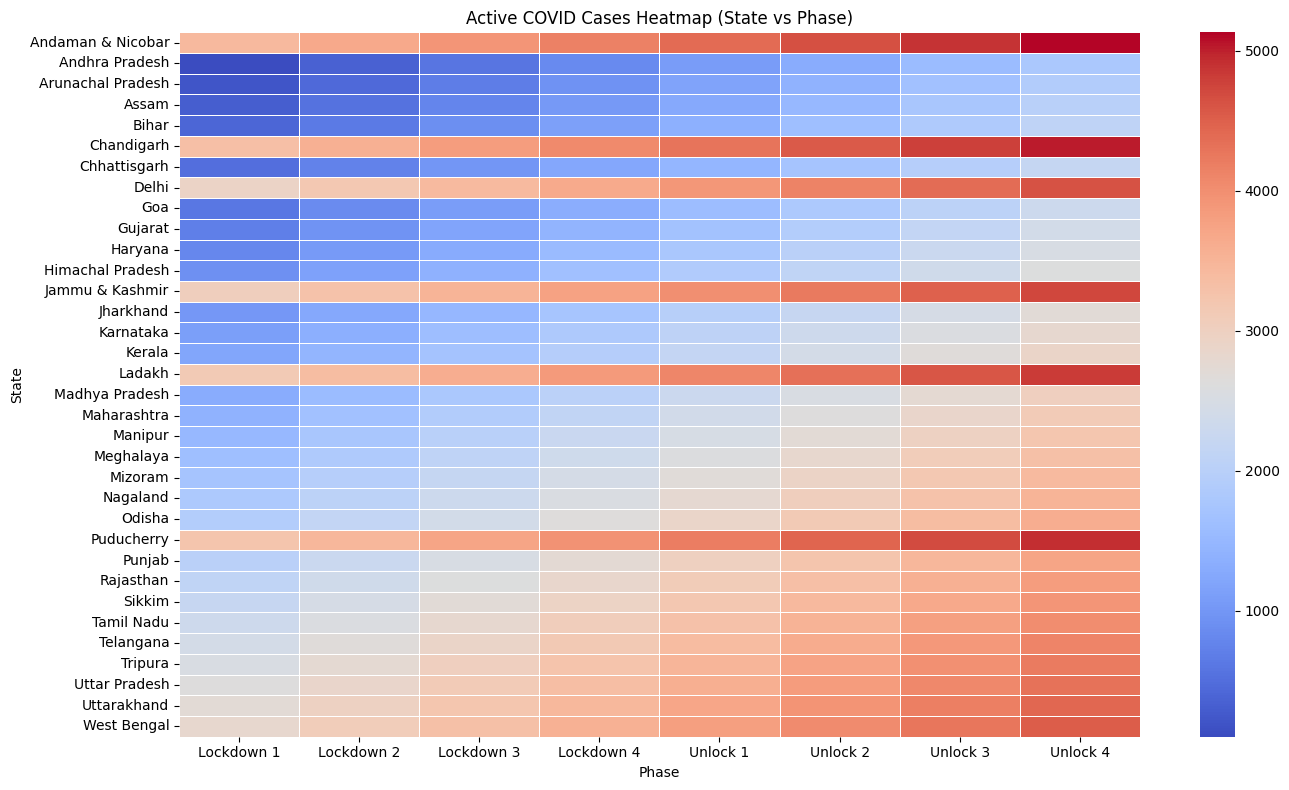

In [21]:
plt.figure(figsize=(14, 8))
sns.heatmap(pivot, cmap='coolwarm', linewidths=0.5)
plt.title("Active COVID Cases Heatmap (State vs Phase)")
plt.xlabel("Phase")
plt.ylabel("State")
plt.tight_layout()
plt.show()